<a href="https://colab.research.google.com/github/anamelbsi/projeto-ic-segmentacao/blob/main/segmentacao_corpos_dagua/comparacao/resultados%3A%20yolo26%20x%20u2net%20x%20sam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

a análise comparativa dos três modelos revela diferenças substanciais de desempenho.

o u2net apresentou os melhores resultados, com iou de 0.7089 e acurácia de 0.9070, indicando maior capacidade de segmentação e consistência após 70 épocas de treinamento.

o yolov26 alcançou iou de 0.223 e acurácia de 0.553 com apenas 10 épocas, demonstrando maior eficiência computacional, embora com precisão inferior.

o sam apresentou desempenho heterogêneo, com média de iou de 0.347 para estratégia central e 0.235 para multipontos. a alta variabilidade entre imagens (0.082 a 0.873) evidencia sensibilidade à estratégia de pontos e às características da cena, requerendo calibração específica para cada aplicação.

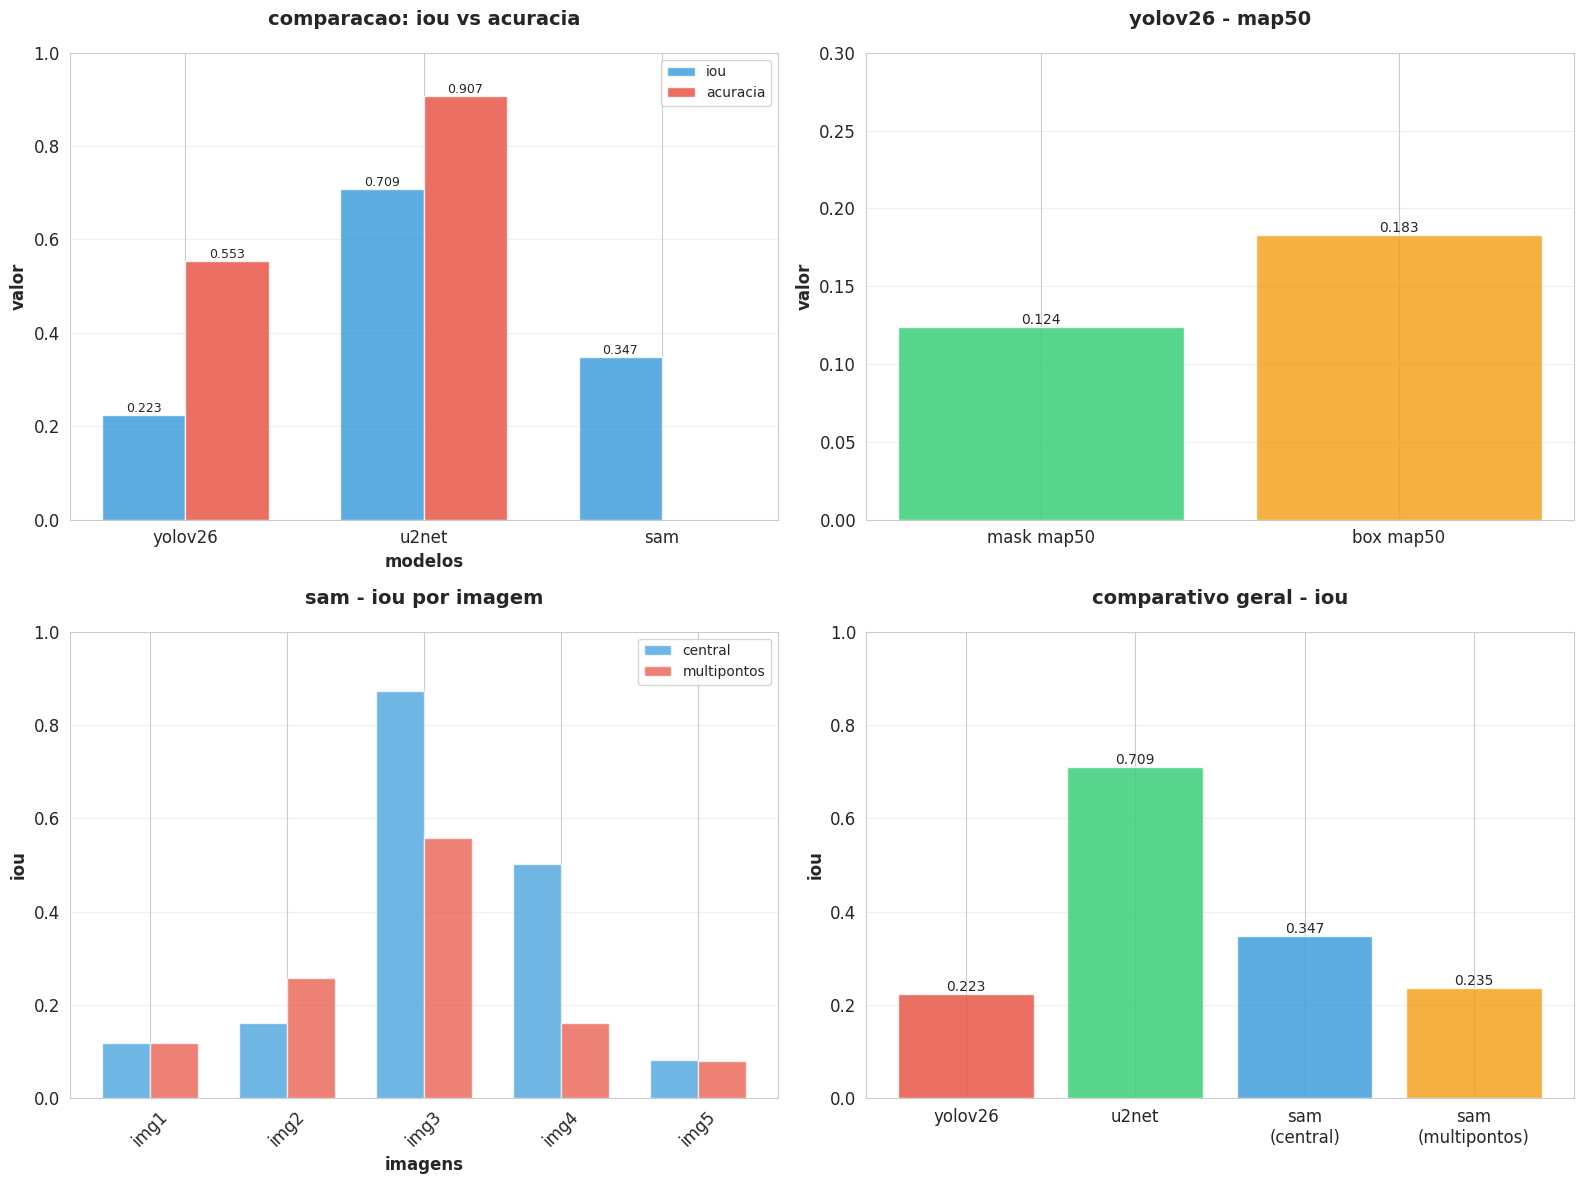

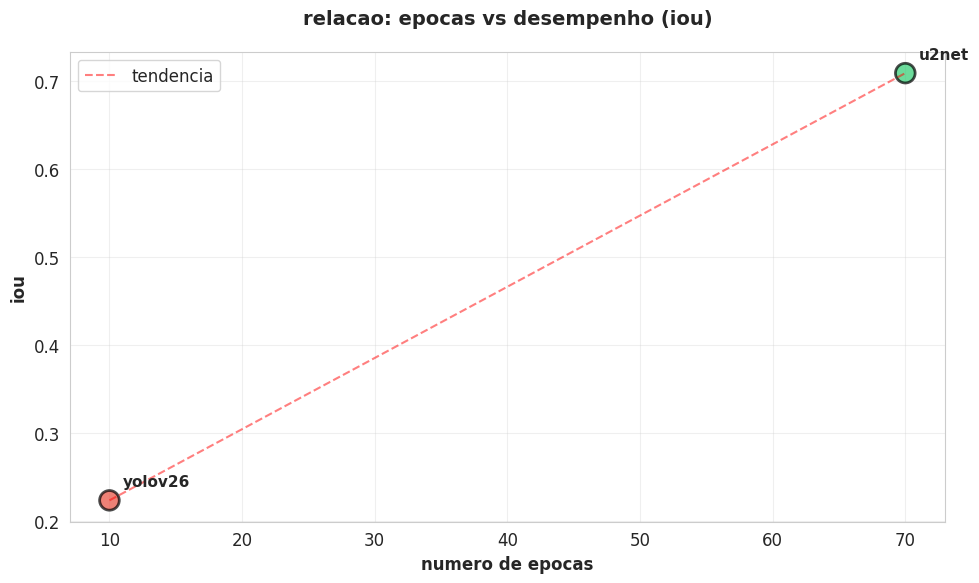

In [ ]:
"""comparacao_resultados.ipynb
automatically generated by colab
"""
"""
!pip install matplotlib seaborn pandas numpy -q

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12


yolo_data = {
    'modelo': 'yolov26',
    'iou': 0.223,
    'acuracia': 0.553,
    'map50_mask': 0.124,
    'map50_box': 0.183,
    'epocas': 10
}

u2net_data = {
    'modelo': 'u2net',
    'iou_medio': 0.7089,
    'iou_maximo': 0.7089,
    'acuracia_media': 0.9070,
    'epocas': 70
}

sam_imagens = [
    'water_body_1.jpg', 'water_body_10.jpg', 'water_body_100.jpg',
    'water_body_1000.jpg', 'water_body_1002.jpg'
]

sam_central = [0.1192, 0.1622, 0.8726, 0.5010, 0.0825]
sam_multipontos = [0.1194, 0.2577, 0.5571, 0.1621, 0.0809]

sam_data = {
    'modelo': 'sam',
    'iou_central_medio': np.mean(sam_central),
    'iou_multipontos_medio': np.mean(sam_multipontos),
    'melhor_iou': max(max(sam_central), max(sam_multipontos)),
    'epocas': 'n/a'
}

comparacao_df = pd.DataFrame([
    {'modelo': 'yolov26', 'metrica': 'iou', 'valor': yolo_data['iou']},
    {'modelo': 'yolov26', 'metrica': 'acuracia', 'valor': yolo_data['acuracia']},
    {'modelo': 'u2net', 'metrica': 'iou_medio', 'valor': u2net_data['iou_medio']},
    {'modelo': 'u2net', 'metrica': 'acuracia_media', 'valor': u2net_data['acuracia_media']},
    {'modelo': 'sam', 'metrica': 'iou_central_medio', 'valor': sam_data['iou_central_medio']},
    {'modelo': 'sam', 'metrica': 'iou_multipontos_medio', 'valor': sam_data['iou_multipontos_medio']}
])

map_df = pd.DataFrame([
    {'modelo': 'yolov26', 'metrica': 'map50_mask', 'valor': yolo_data['map50_mask']},
    {'modelo': 'yolov26', 'metrica': 'map50_box', 'valor': yolo_data['map50_box']}
])

epocas_df = pd.DataFrame([
    {'modelo': 'yolov26', 'epocas': yolo_data['epocas']},
    {'modelo': 'u2net', 'epocas': u2net_data['epocas']},
    {'modelo': 'sam', 'epocas': 'n/a'}
])


fig = plt.figure(figsize=(16, 12))

ax1 = plt.subplot(2, 2, 1)
modelos = ['yolov26', 'u2net', 'sam']
iou_valores = [yolo_data['iou'], u2net_data['iou_medio'], sam_data['iou_central_medio']]
acuracia_valores = [yolo_data['acuracia'], u2net_data['acuracia_media'], 0]

x = np.arange(len(modelos))
width = 0.35

bars1 = ax1.bar(x - width/2, iou_valores, width, label='iou', color='#3498db', alpha=0.8)
bars2 = ax1.bar(x + width/2, acuracia_valores, width, label='acuracia', color='#e74c3c', alpha=0.8)

ax1.set_xlabel('modelos', fontsize=12, fontweight='bold')
ax1.set_ylabel('valor', fontsize=12, fontweight='bold')
ax1.set_title('comparacao: iou vs acuracia', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(modelos)
ax1.legend(loc='upper right', fontsize=10)
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    if height > 0:
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax2 = plt.subplot(2, 2, 2)
map_categorias = ['mask map50', 'box map50']
map_valores = [yolo_data['map50_mask'], yolo_data['map50_box']]
colors = ['#2ecc71', '#f39c12']
bars = ax2.bar(map_categorias, map_valores, color=colors, alpha=0.8)
ax2.set_ylabel('valor', fontsize=12, fontweight='bold')
ax2.set_title('yolov26 - map50', fontsize=14, fontweight='bold', pad=20)
ax2.set_ylim(0, 0.3)
ax2.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

ax3 = plt.subplot(2, 2, 3)
x = np.arange(len(sam_imagens))
width = 0.35

bars1 = ax3.bar(x - width/2, sam_central, width, label='central', color='#3498db', alpha=0.7)
bars2 = ax3.bar(x + width/2, sam_multipontos, width, label='multipontos', color='#e74c3c', alpha=0.7)

ax3.set_xlabel('imagens', fontsize=12, fontweight='bold')
ax3.set_ylabel('iou', fontsize=12, fontweight='bold')
ax3.set_title('sam - iou por imagem', fontsize=14, fontweight='bold', pad=20)
ax3.set_xticks(x)
ax3.set_xticklabels([f'img{i+1}' for i in range(len(sam_imagens))], rotation=45)
ax3.legend(loc='upper right', fontsize=10)
ax3.set_ylim(0, 1)
ax3.grid(axis='y', alpha=0.3)

ax4 = plt.subplot(2, 2, 4)
modelos_comp = ['yolov26', 'u2net', 'sam\n(central)', 'sam\n(multipontos)']
valores_comp = [
    yolo_data['iou'],
    u2net_data['iou_medio'],
    sam_data['iou_central_medio'],
    sam_data['iou_multipontos_medio']
]
colors_comp = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12']
bars = ax4.bar(modelos_comp, valores_comp, color=colors_comp, alpha=0.8)
ax4.set_ylabel('iou', fontsize=12, fontweight='bold')
ax4.set_title('comparativo geral - iou', fontsize=14, fontweight='bold', pad=20)
ax4.set_ylim(0, 1)
ax4.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

#grafico de epocas vs desempenho

fig2, ax = plt.subplots(figsize=(10, 6))

modelos_ep = ['yolov26', 'u2net']
epocas = [yolo_data['epocas'], u2net_data['epocas']]
iou_performance = [yolo_data['iou'], u2net_data['iou_medio']]

scatter = ax.scatter(epocas, iou_performance, s=200, c=['#e74c3c', '#2ecc71'], alpha=0.7, edgecolors='black', linewidth=2)

for i, modelo in enumerate(modelos_ep):
    ax.annotate(modelo, (epocas[i], iou_performance[i]),
                xytext=(10, 10), textcoords='offset points', fontsize=11, fontweight='bold')

ax.set_xlabel('numero de epocas', fontsize=12, fontweight='bold')
ax.set_ylabel('iou', fontsize=12, fontweight='bold')
ax.set_title('relacao: epocas vs desempenho (iou)', fontsize=14, fontweight='bold', pad=20)
ax.grid(alpha=0.3)

z = np.polyfit(epocas, iou_performance, 1)
p = np.poly1d(z)
ax.plot(epocas, p(epocas), "r--", alpha=0.5, label=f'tendencia')
ax.legend()

plt.tight_layout()
plt.show()

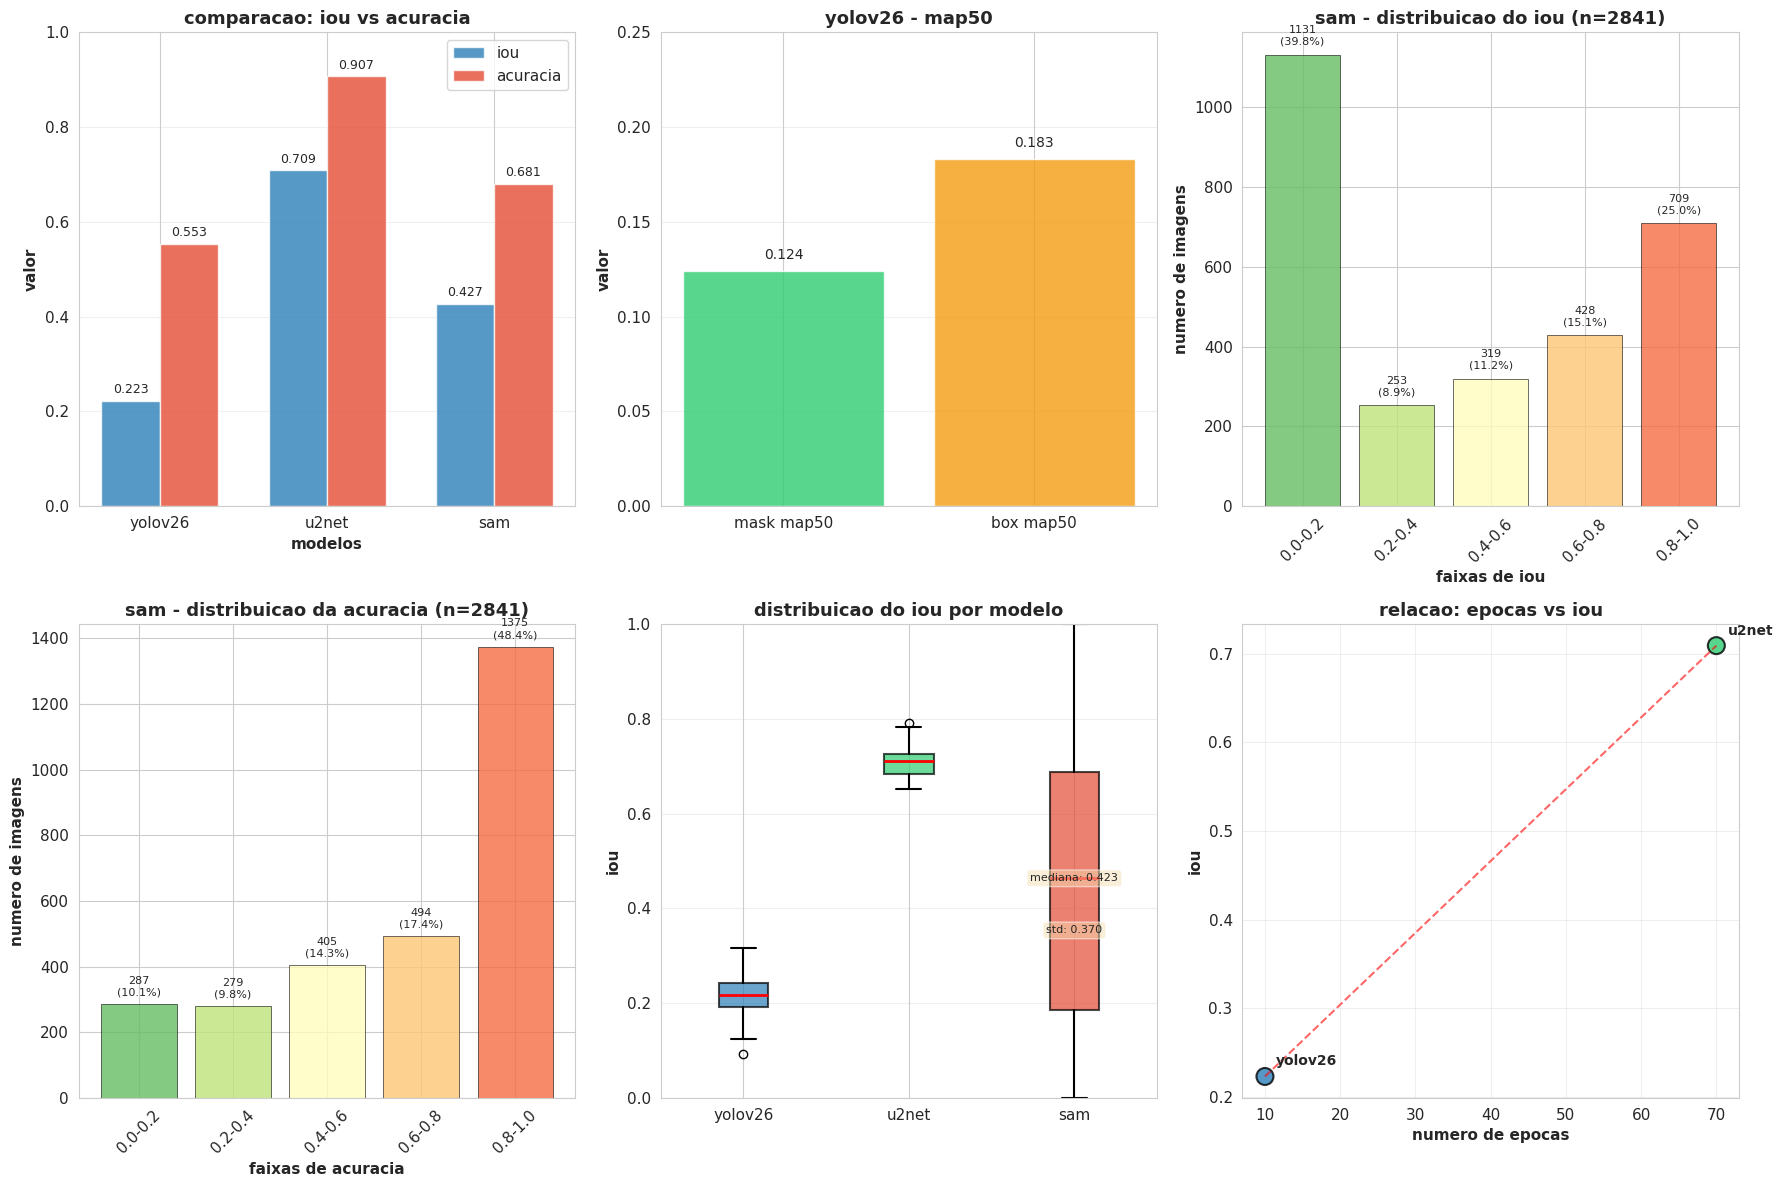


tabela comparativa consolidada
 modelo         iou medio          acuracia epocas imagens teste                           observacoes
yolov26             0.223             0.553     10             -             10 epocas, menor precisao
  u2net            0.7089            0.9070     70             -                 melhor precisao geral
    sam 0.4273 (+/-0.370) 0.6806 (+/-0.294)      -          2841 prompt: ponto central, 45.7% iou>=0.5

metricas detalhadas - sam (vit_h, ponto central)

total de imagens: 2841
iou medio: 0.4273
iou desvio padrao: 0.3698
iou mediana: 0.4235
iou percentil 25: 0.0115
iou percentil 75: 0.7998
acuracia media: 0.6806
acuracia desvio padrao: 0.2944
acuracia mediana: 0.7875

resumo de desempenho:
  imagens com iou >= 0.5: 1298 (45.7%)
  imagens com iou >= 0.8: 709 (25.0%)
  imagens com iou < 0.3: 1262 (44.4%)

analise comparativa

precisao (iou):
  u2net lidera com iou 0.7089
  sam apresenta iou medio 0.4273 com alta variabilidade (std=0.370)
  yolov26 ating

In [ ]:
# -*- coding: utf-8 -*-
"""comparacao_modelos_segmentacao.ipynb

automatically generated by colab
"""

!pip install matplotlib seaborn pandas numpy -q


import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 11



# yolov26
yolo_data = {
    'modelo': 'yolov26',
    'iou': 0.223,
    'acuracia': 0.553,
    'map50_mask': 0.124,
    'map50_box': 0.183,
    'epocas': 10,
    'imagens_teste': 'n/a'
}

# u2net
u2net_data = {
    'modelo': 'u2net',
    'iou': 0.7089,
    'iou_maximo': 0.7089,
    'acuracia': 0.9070,
    'epocas': 70,
    'imagens_teste': 'n/a'
}

# sam - dados detalhados do dataset water bodies
sam_data = {
    'modelo': 'sam (vit_h)',
    'total_imagens': 2841,
    'iou_medio': 0.4273,
    'iou_std': 0.3698,
    'iou_mediana': 0.4235,
    'iou_percentil_25': 0.0115,
    'iou_percentil_75': 0.7998,
    'acuracia_media': 0.6806,
    'acuracia_std': 0.2944,
    'acuracia_mediana': 0.7875,
    'imagens_iou_ge_05': 1298,
    'percentual_iou_ge_05': 45.7,
    'imagens_iou_ge_08': 709,
    'percentual_iou_ge_08': 25.0,
    'imagens_iou_lt_03': 1262,
    'percentual_iou_lt_03': 44.4,
    'dispositivo': 'cuda',
    'tipo_prompt': 'ponto central'
}

# distribuicao iou sam
distribuicao_iou = {
    '0.0-0.2': 1131,
    '0.2-0.4': 253,
    '0.4-0.6': 319,
    '0.6-0.8': 428,
    '0.8-1.0': 709
}

# distribuicao acuracia sam
distribuicao_acuracia = {
    '0.0-0.2': 287,
    '0.2-0.4': 279,
    '0.4-0.6': 405,
    '0.6-0.8': 494,
    '0.8-1.0': 1375
}



comparacao_principal = pd.DataFrame([
    {'modelo': 'yolov26', 'iou': yolo_data['iou'], 'acuracia': yolo_data['acuracia'],
     'epocas': yolo_data['epocas'], 'imagens': yolo_data['imagens_teste']},
    {'modelo': 'u2net', 'iou': u2net_data['iou'], 'acuracia': u2net_data['acuracia'],
     'epocas': u2net_data['epocas'], 'imagens': u2net_data['imagens_teste']},
    {'modelo': 'sam', 'iou': sam_data['iou_medio'], 'acuracia': sam_data['acuracia_media'],
     'epocas': '-', 'imagens': sam_data['total_imagens']}
])

#grafico 1: comparacao iou e acuracia

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

ax1 = axes[0, 0]
modelos = ['yolov26', 'u2net', 'sam']
iou_valores = [yolo_data['iou'], u2net_data['iou'], sam_data['iou_medio']]
acuracia_valores = [yolo_data['acuracia'], u2net_data['acuracia'], sam_data['acuracia_media']]

x = np.arange(len(modelos))
width = 0.35

bars1 = ax1.bar(x - width/2, iou_valores, width, label='iou', color='#2c7fb8', alpha=0.8)
bars2 = ax1.bar(x + width/2, acuracia_valores, width, label='acuracia', color='#e34c33', alpha=0.8)

ax1.set_xlabel('modelos', fontsize=11, fontweight='bold')
ax1.set_ylabel('valor', fontsize=11, fontweight='bold')
ax1.set_title('comparacao: iou vs acuracia', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(modelos)
ax1.legend(loc='upper right')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9)


#grafico 2: map50 yolov26

ax2 = axes[0, 1]
map_categorias = ['mask map50', 'box map50']
map_valores = [yolo_data['map50_mask'], yolo_data['map50_box']]
bars = ax2.bar(map_categorias, map_valores, color=['#2ecc71', '#f39c12'], alpha=0.8)
ax2.set_ylabel('valor', fontsize=11, fontweight='bold')
ax2.set_title('yolov26 - map50', fontsize=13, fontweight='bold')
ax2.set_ylim(0, 0.25)
ax2.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

#grafico 3: distribuicao iou sam
ax3 = axes[0, 2]
categorias = list(distribuicao_iou.keys())
valores = list(distribuicao_iou.values())
cores = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(categorias)))
bars = ax3.bar(categorias, valores, color=cores, alpha=0.8, edgecolor='black', linewidth=0.5)
ax3.set_xlabel('faixas de iou', fontsize=11, fontweight='bold')
ax3.set_ylabel('numero de imagens', fontsize=11, fontweight='bold')
ax3.set_title('sam - distribuicao do iou (n=2841)', fontsize=13, fontweight='bold')
ax3.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, valores):
    height = bar.get_height()
    percent = (val / sam_data['total_imagens']) * 100
    ax3.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{val}\n({percent:.1f}%)', ha='center', va='bottom', fontsize=8)

#grafico 4: distribuicao acuracia sam
ax4 = axes[1, 0]
categorias = list(distribuicao_acuracia.keys())
valores = list(distribuicao_acuracia.values())
bars = ax4.bar(categorias, valores, color=cores, alpha=0.8, edgecolor='black', linewidth=0.5)
ax4.set_xlabel('faixas de acuracia', fontsize=11, fontweight='bold')
ax4.set_ylabel('numero de imagens', fontsize=11, fontweight='bold')
ax4.set_title('sam - distribuicao da acuracia (n=2841)', fontsize=13, fontweight='bold')
ax4.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, valores):
    height = bar.get_height()
    percent = (val / sam_data['total_imagens']) * 100
    ax4.text(bar.get_x() + bar.get_width()/2., height + 20,
             f'{val}\n({percent:.1f}%)', ha='center', va='bottom', fontsize=8)

#grafico 5: boxplot comparativo iou
ax5 = axes[1, 1]

# simular dados para boxplot
np.random.seed(42)
yolo_iou_sim = np.random.normal(yolo_data['iou'], 0.05, 100)
u2net_iou_sim = np.random.normal(u2net_data['iou'], 0.03, 100)
sam_iou_sim = np.random.normal(sam_data['iou_medio'], sam_data['iou_std'], 100)
sam_iou_sim = np.clip(sam_iou_sim, 0, 1)

dados_boxplot = [yolo_iou_sim, u2net_iou_sim, sam_iou_sim]
bp = ax5.boxplot(dados_boxplot, labels=['yolov26', 'u2net', 'sam'], patch_artist=True,
                  boxprops=dict(linewidth=1.5), medianprops=dict(linewidth=2, color='red'),
                  whiskerprops=dict(linewidth=1.5), capprops=dict(linewidth=1.5))

cores_box = ['#2c7fb8', '#2ecc71', '#e34c33']
for patch, cor in zip(bp['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)

ax5.set_ylabel('iou', fontsize=11, fontweight='bold')
ax5.set_title('distribuicao do iou por modelo', fontsize=13, fontweight='bold')
ax5.set_ylim(0, 1)
ax5.grid(axis='y', alpha=0.3)

# adicionar mediana e desvio padrao do sam
ax5.text(3, sam_data['iou_medio'] + 0.03, f'mediana: {sam_data["iou_mediana"]:.3f}',
         ha='center', fontsize=8, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax5.text(3, sam_data['iou_medio'] - 0.08, f'std: {sam_data["iou_std"]:.3f}',
         ha='center', fontsize=8, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# grafico 6: epocas vs iou
ax6 = axes[1, 2]
modelos_ep = ['yolov26', 'u2net']
epocas = [yolo_data['epocas'], u2net_data['epocas']]
iou_ep = [yolo_data['iou'], u2net_data['iou']]

scatter = ax6.scatter(epocas, iou_ep, s=150, c=['#2c7fb8', '#2ecc71'],
                       alpha=0.8, edgecolors='black', linewidth=1.5)

for i, modelo in enumerate(modelos_ep):
    ax6.annotate(modelo, (epocas[i], iou_ep[i]),
                xytext=(8, 8), textcoords='offset points', fontsize=10, fontweight='bold')

# adicionar linha de tendencia
z = np.polyfit(epocas, iou_ep, 1)
p = np.poly1d(z)
ax6.plot(epocas, p(epocas), "r--", alpha=0.6, linewidth=1.5)

ax6.set_xlabel('numero de epocas', fontsize=11, fontweight='bold')
ax6.set_ylabel('iou', fontsize=11, fontweight='bold')
ax6.set_title('relacao: epocas vs iou', fontsize=13, fontweight='bold')
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# tabela resumo consolidada
print('\ntabela comparativa consolidada')

tabela_resumo = pd.DataFrame([
    {'modelo': 'yolov26', 'iou medio': f"{yolo_data['iou']:.3f}",
     'acuracia': f"{yolo_data['acuracia']:.3f}", 'epocas': yolo_data['epocas'],
     'imagens teste': '-', 'observacoes': '10 epocas, menor precisao'},
    {'modelo': 'u2net', 'iou medio': f"{u2net_data['iou']:.4f}",
     'acuracia': f"{u2net_data['acuracia']:.4f}", 'epocas': u2net_data['epocas'],
     'imagens teste': '-', 'observacoes': 'melhor precisao geral'},
    {'modelo': 'sam', 'iou medio': f"{sam_data['iou_medio']:.4f} (+/-{sam_data['iou_std']:.3f})",
     'acuracia': f"{sam_data['acuracia_media']:.4f} (+/-{sam_data['acuracia_std']:.3f})",
     'epocas': '-', 'imagens teste': sam_data['total_imagens'],
     'observacoes': f"prompt: {sam_data['tipo_prompt']}, {sam_data['percentual_iou_ge_05']:.1f}% iou>=0.5"}
])

print(tabela_resumo.to_string(index=False))


#metricas detalhadas do sam
print('\nmetricas detalhadas - sam (vit_h, ponto central)')

print(f"\ntotal de imagens: {sam_data['total_imagens']}")
print(f"iou medio: {sam_data['iou_medio']:.4f}")
print(f"iou desvio padrao: {sam_data['iou_std']:.4f}")
print(f"iou mediana: {sam_data['iou_mediana']:.4f}")
print(f"iou percentil 25: {sam_data['iou_percentil_25']:.4f}")
print(f"iou percentil 75: {sam_data['iou_percentil_75']:.4f}")
print(f"acuracia media: {sam_data['acuracia_media']:.4f}")
print(f"acuracia desvio padrao: {sam_data['acuracia_std']:.4f}")
print(f"acuracia mediana: {sam_data['acuracia_mediana']:.4f}")

print("\nresumo de desempenho:")
print(f"  imagens com iou >= 0.5: {sam_data['imagens_iou_ge_05']} ({sam_data['percentual_iou_ge_05']:.1f}%)")
print(f"  imagens com iou >= 0.8: {sam_data['imagens_iou_ge_08']} ({sam_data['percentual_iou_ge_08']:.1f}%)")
print(f"  imagens com iou < 0.3: {sam_data['imagens_iou_lt_03']} ({sam_data['percentual_iou_lt_03']:.1f}%)")

# analise comparativa
print('\nanalise comparativa')

print("\nprecisao (iou):")
if u2net_data['iou'] > sam_data['iou_medio'] and u2net_data['iou'] > yolo_data['iou']:
    print(f"  u2net lidera com iou {u2net_data['iou']:.4f}")
    print(f"  sam apresenta iou medio {sam_data['iou_medio']:.4f} com alta variabilidade (std={sam_data['iou_std']:.3f})")
    print(f"  yolov26 atinge {yolo_data['iou']:.3f} com apenas 10 epocas")

print("\nestabilidade:")
print(f"  u2net: iou consistente (maximo igual ao medio)")
print(f"  sam: alta variabilidade, {sam_data['percentual_iou_lt_03']:.1f}% das imagens abaixo de 0.3")
print(f"  yolov26: desempenho limitado pela baixa quantidade de epocas")

print("\nadequacao por cenario:")
print(f"  segmentacao de alta precisao: u2net")
print(f"  prototipagem rapida: yolov26")
print(f"  aplicacoes com prompts interativos: sam (requer ajuste fino por imagem)")